In [54]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pickle

from editdistance import eval as edit_distance

from simplipy import SimpliPyEngine

from tqdm import tqdm

from flash_ansr import get_path
from flash_ansr.eval.metrics import bootstrapped_metric_ci, zss_tree_edit_distance
from flash_ansr.eval.metrics.token_prediction import f1_score, precision, recall

In [55]:
# This is where the results are stored
PATH_TO_EVALUATION_DATA = get_path('results', 'evaluation', 'scaling')
os.path.exists(PATH_TO_EVALUATION_DATA)

True

In [56]:
engine = SimpliPyEngine.load('dev_7-3', install=True)

In [57]:
# We will compare the rebuttal experiments: SimpliPy vs SymPy vs Unsimplified
results = {
    'v23.0-20M-A-S1': {'scaling_parameter': 'choices'},
    'v23.0-20M-A-Y1': {'scaling_parameter': 'choices'},
    'v23.0-20M-A-U1': {'scaling_parameter': 'choices'},
    'v23.0-20M-A-Y50K': {'scaling_parameter': 'choices'},
    'v23.0-20M-A-Y1-simplipy-infer': {'scaling_parameter': 'choices'},
}

In [58]:
TEST_SETS = ['fastsrb']
TEST_SETS

['fastsrb']

In [59]:
models_not_found = []
for model in results.keys():
    scaling_parameter = results[model]['scaling_parameter']
    results[model]['evaluations_list'] = {}
    found_dataset = False
    for dataset in TEST_SETS:
        try:
            evaluations_list = os.listdir(os.path.join(PATH_TO_EVALUATION_DATA, model, dataset))
            found_dataset = True
        except FileNotFoundError:
            print(f"{os.path.join(PATH_TO_EVALUATION_DATA, model, dataset)} not found, skipping.")
            continue

        evaluations_list = [d for d in evaluations_list if d.startswith(f'{scaling_parameter}_')]
        scaling_values = [int(d.split('_')[-1].split('.')[0]) for d in evaluations_list]

        scaling_values_argsort = np.argsort(scaling_values)
        scaling_values = [scaling_values[i] for i in scaling_values_argsort]
        evaluations_list = [evaluations_list[i] for i in scaling_values_argsort]

        results[model]['scaling_values'] = scaling_values
        results[model]['evaluations_list'][dataset] = evaluations_list
        results[model]['results'] = {}

        print(f"{model}: Found {len(evaluations_list)} evaluations with scaling values: {scaling_values}")
        for d in evaluations_list:
            print(f" - {d}")

    if not found_dataset:
        print(f"No datasets found for model {model}, removing from results.")
        models_not_found.append(model)

for model_not_found in models_not_found:
    del results[model_not_found]

v23.0-20M-A-S1: Found 6 evaluations with scaling values: [1, 4, 16, 64, 256, 1024]
 - choices_00001.pkl
 - choices_00004.pkl
 - choices_00016.pkl
 - choices_00064.pkl
 - choices_00256.pkl
 - choices_01024.pkl
v23.0-20M-A-Y1: Found 6 evaluations with scaling values: [1, 4, 16, 64, 256, 1024]
 - choices_00001.pkl
 - choices_00004.pkl
 - choices_00016.pkl
 - choices_00064.pkl
 - choices_00256.pkl
 - choices_01024.pkl
v23.0-20M-A-U1: Found 6 evaluations with scaling values: [1, 4, 16, 64, 256, 1024]
 - choices_00001.pkl
 - choices_00004.pkl
 - choices_00016.pkl
 - choices_00064.pkl
 - choices_00256.pkl
 - choices_01024.pkl
v23.0-20M-A-Y50K: Found 6 evaluations with scaling values: [1, 4, 16, 64, 256, 1024]
 - choices_00001.pkl
 - choices_00004.pkl
 - choices_00016.pkl
 - choices_00064.pkl
 - choices_00256.pkl
 - choices_01024.pkl
v23.0-20M-A-Y1-simplipy-infer: Found 6 evaluations with scaling values: [1, 4, 16, 64, 256, 1024]
 - choices_00001.pkl
 - choices_00004.pkl
 - choices_00016.pkl
 

In [60]:
# Load the evaluation results
for model in results.keys():
    scaling_parameter = results[model]['scaling_parameter']
    for dataset in TEST_SETS:
        if dataset not in results[model]['evaluations_list']:
            continue
        for d in tqdm(results[model]['evaluations_list'][dataset], desc="Loading evaluation results"):
            for test_set in TEST_SETS:
                path_to_pickle = os.path.join(PATH_TO_EVALUATION_DATA, model, test_set, d)
                if not os.path.exists(path_to_pickle):
                    print(f"Warning: {path_to_pickle} does not exist. Skipping.")
                    continue
                with open(path_to_pickle, 'rb') as f:
                    # print(f"Loading {path_to_pickle}...")
                    try:
                        result = pickle.load(f)
                    except Exception as e:
                        print(f"Error loading {path_to_pickle}: {e}")
                        continue
                scaling_parameter_value = int(d.split('_')[-1].split('.')[0])
                if test_set not in results[model]['results']:
                    results[model]['results'][test_set] = {}
                results[model]['results'][test_set][scaling_parameter_value] = result

    print(f"{model} {list(results[model]['results'].keys())}")

Loading evaluation results: 100%|██████████| 6/6 [00:00<00:00, 24.19it/s]


v23.0-20M-A-S1 ['fastsrb']


Loading evaluation results: 100%|██████████| 6/6 [00:00<00:00, 24.72it/s]


v23.0-20M-A-Y1 ['fastsrb']


Loading evaluation results: 100%|██████████| 6/6 [00:00<00:00, 31.54it/s]


v23.0-20M-A-U1 ['fastsrb']


Loading evaluation results: 100%|██████████| 6/6 [00:00<00:00, 23.84it/s]


v23.0-20M-A-Y50K ['fastsrb']


Loading evaluation results: 100%|██████████| 6/6 [00:00<00:00, 25.73it/s]

v23.0-20M-A-Y1-simplipy-infer ['fastsrb']


In [61]:
# Sort the results[model]['results']['fastsrb'].keys() and similar ones
for model in results.keys():
    for test_set in TEST_SETS:
        if test_set in results[model]['results']:
            sorted_keys = sorted(results[model]['results'][test_set].keys())
            results[model]['results'][test_set] = {k: results[model]['results'][test_set][k] for k in sorted_keys}

In [62]:
DEFAULT_NEGATIVES = {
    'constants': [],
    'error': None,
    'skeleton': [],
    'skeleton_simplified': [],
    'expression': [],
    'variables': [],
    'variable_names': [],
    'complexity': np.nan,
    'placeholder_reason': None,
    'benchmark_metadata': {},
    'ground_truth_infix': [],
    'ground_truth_prefix': [],
    'fit_time': np.inf,
    'input_ids': [],
    'labels': [],
    'labels_decoded': [],
    'n_support': np.nan,
    'parsimony': np.nan,
    'predicted_expression': [],
    'predicted_expression_prefix': [],
    'predicted_skeleton_prefix': [],
    'predicted_skeleton_prefix_raw': [],
    'predicted_constants': [],
    'predicted_score': -np.inf,
    'predicted_log_prob': -np.inf,
    'prediction_success': False,
    'skeleton': [],
    'skeleton_hash': [],
    'x': np.nan,
    'x_val': np.nan,
    'y': np.nan,
    'y_noisy': np.nan,
    'y_noisy_val': np.nan,
    'y_pred': np.nan,
    'y_pred_val': np.nan,
    'y_val': np.nan,

    'f1_score': 0.0,
    'skeleton_length': np.inf,
    'expression_length': np.inf,
    'predicted_skeleton_prefix_length': np.inf,
    'fvu_fit': np.inf,
    'fvu_val': np.inf,
    'log10_fvu_fit': np.inf,
    'log10_fvu_val': np.inf,
    'only_approx_fvu_fit': np.inf,
    'only_approx_fvu_val': np.inf,
    'only_approx_log10_fvu_fit': np.inf,
    'only_approx_log10_fvu_val': np.inf,
    'numeric_recovery_fit': 0.0,
    'numeric_recovery_val': 0.0,
    'n_variables': np.nan,
    'n_constants': np.inf,
    'predicted_n_constants': np.inf,
    'n_constants_delta': np.inf,
    'symbolic_recovery': 0.0,
    'skeleton_length_ratio': np.inf,
    'edit_distance': np.inf,
    'zss_edit_distance': np.inf,
    'unique_variables': np.nan,
    'predicted_unique_variables': 0,
    'f1_score_unique_variables': 0.0,
    'precision_unique_variables': 0.0,
    'recall_unique_variables': 0.0,
    'total_nestedness': np.nan,
    'predicted_total_nestedness': np.inf,
}

In [63]:
for model in results.keys():
    for test_set in results[model]['results'].keys():
        for niterations in results[model]['results'][test_set].keys():
            for metric in results[model]['results'][test_set][niterations].keys():
                try:
                    results[model]['results'][test_set][niterations][metric] = [(DEFAULT_NEGATIVES.get(metric, np.nan) if r is None else r) for r in results[model]['results'][test_set][niterations][metric]]
                    if not isinstance(DEFAULT_NEGATIVES.get(metric, np.nan), list):
                        results[model]['results'][test_set][niterations][metric] = np.array(results[model]['results'][test_set][niterations][metric])
                except ValueError:
                    pass  # setting an array element with a sequence

In [64]:
# No variable renaming needed for rebuttal models (only Flash-ANSR variants)

In [65]:
def safe_divide(a, b):
    if b == 0:
        if a == 0:
            return 0
        return np.inf
    if np.isnan(a) or np.isnan(b):
        return np.nan
    if not np.isfinite(a) or not np.isfinite(b):
        print(a, b)
    return a / b

def fvu(y_true, y_pred):
    if y_pred is None or y_true is None:
        return np.inf
        
    if not isinstance(y_pred, np.ndarray) and np.isnan(y_pred):
        return np.inf

    y_pred = y_pred.astype(np.float64).ravel()
    y_true = y_true.astype(np.float64).ravel()

    # Check if the ground truth is finite but the prediction is not
    if np.isfinite(y_true).all() and not np.isfinite(y_pred).all():
        return np.inf

    # Scale y_true and y_pred by the inverse of the mean squared error to avoid numerical issues
    ss_res = np.mean((y_true - y_pred) ** 2)
    if ss_res == 0:
        return 0
    scale = 1 / ss_res

    ss_res = np.mean((y_true * scale - y_pred * scale) ** 2)
    ss_tot = np.mean((y_true * scale - np.mean(y_true * scale, keepdims=True)) ** 2)

    return safe_divide(ss_res, ss_tot)

def log10_fvu(y_true, y_pred):
    fvu_value = fvu(y_true, y_pred)
    if fvu_value == 0:
        return -np.inf
    return np.log10(fvu_value)

def is_perfect_fit(y_true, y_pred):
    return fvu(y_true, y_pred) <= np.finfo(np.float32).eps

def total_nestedness(prefix_skeleton: list[str]) -> int:
    nestedness = 0
    current_depth = 0
    for i, token in enumerate(prefix_skeleton):
        if engine.operator_arity.get(token, 0) == 1:
            current_depth += 1
        else:
            nestedness += max(0, current_depth - 1)
            current_depth = 0

    return nestedness

for model in tqdm(results.keys()):
    for test_set in results[model]['results'].keys():
        for scaling_value in results[model]['results'][test_set].keys():
            for split, saved_split_name in zip(['fit', 'val'], ['', '_val']):
                r = results[model]['results'][test_set][scaling_value]
                r[f'fvu_{split}'] = np.array([fvu(y_true, y_pred) for y_true, y_pred in zip(r[f'y{saved_split_name}'], r[f'y_pred{saved_split_name}'])])
                r[f'log10_fvu_{split}'] = np.array([log10_fvu(y_true, y_pred) for y_true, y_pred in zip(r[f'y{saved_split_name}'], r[f'y_pred{saved_split_name}'])])
                r[f'numeric_recovery_{split}'] = np.array([is_perfect_fit(y_true, y_pred) for y_true, y_pred in zip(r[f'y{saved_split_name}'], r[f'y_pred{saved_split_name}'])])

                r[f'only_approx_fvu_{split}'] = np.where(r[f'numeric_recovery_{split}'], -np.inf, r[f'fvu_{split}'])
                r[f'only_approx_log10_fvu_{split}'] = np.where(r[f'numeric_recovery_{split}'], -np.inf, r[f'log10_fvu_{split}'])

            r[f'skeleton_simplified'] = [
                engine.simplify(skeleton, max_pattern_length=4) if skeleton is not None else None
                for skeleton in r['skeleton']]

            r['f1_score'] = np.array([
                f1_score(np.array([predicted_skeleton_prefix]), np.array([skeleton])) if predicted_skeleton_prefix is not None else None  # Will be filled with default negatives in the cell below
                for predicted_skeleton_prefix, skeleton in zip(r['predicted_skeleton_prefix'], r['skeleton_simplified'])])

            r['skeleton_length'] = np.array([
                len(skeleton) if skeleton is not None else None
                for skeleton in r['skeleton_simplified']])
            
            r['predicted_skeleton_prefix_length'] = np.array([
                len(predicted_skeleton_prefix) if predicted_skeleton_prefix is not None else None
                for predicted_skeleton_prefix in r['predicted_skeleton_prefix']])
            
            r['n_variables'] = np.array([
                len(set(token for token in skeleton if token.startswith('x'))) if skeleton is not None else None
                for skeleton in r['skeleton_simplified']])
            
            r['n_constants'] = np.array([
                skeleton.count('<constant>') if skeleton is not None else None
                for skeleton in r['skeleton_simplified']])
            
            r['predicted_n_constants'] = np.array([
                predicted_skeleton_prefix.count('<constant>') if predicted_skeleton_prefix is not None else None
                for predicted_skeleton_prefix in r['predicted_skeleton_prefix']])
            
            r['n_constants_delta'] = np.array([
                predicted_n_constants - true_n_constants if predicted_n_constants is not None and true_n_constants is not None else None
                for predicted_n_constants, true_n_constants in zip(r['predicted_n_constants'], r['n_constants'])])

            r[f'symbolic_recovery'] = np.array([
                predicted_skeleton_prefix == skeleton if predicted_skeleton_prefix is not None else None
                for predicted_skeleton_prefix, skeleton in zip(r['predicted_skeleton_prefix'], r['skeleton_simplified'])])

            r[f'skeleton_length_ratio'] = np.array([
                safe_divide(predicted_length, true_length) if predicted_length is not None and true_length is not None else None
                for predicted_length, true_length in zip(r['predicted_skeleton_prefix_length'], r['skeleton_length'])])

            r['edit_distance'] = np.array([
                edit_distance(predicted_skeleton_prefix, skeleton) if predicted_skeleton_prefix is not None and skeleton is not None else None
                for predicted_skeleton_prefix, skeleton in zip(r['predicted_skeleton_prefix'], r['skeleton_simplified'])])
            
            r['zss_edit_distance'] = np.array([
                zss_tree_edit_distance(predicted_skeleton_prefix, skeleton, engine.operator_arity) if predicted_skeleton_prefix is not None and skeleton is not None else None
                for predicted_skeleton_prefix, skeleton in zip(r['predicted_skeleton_prefix'], r['skeleton_simplified'])])
            
            r['unique_variables'] = [
                sorted(list(set(token for token in skeleton if token.startswith('x'))), key=lambda x: int(x[1:])) if skeleton is not None else None
                for skeleton in r['skeleton_simplified']]

            r['predicted_unique_variables'] = [
                sorted(list(set(token for token in predicted_skeleton_prefix if token.startswith('x'))), key=lambda x: int(x[1:])) if predicted_skeleton_prefix is not None else None
                for predicted_skeleton_prefix in r['predicted_skeleton_prefix']]
            
            r['f1_score_unique_variables'] = np.array([
                f1_score([predicted_unique_variables], [unique_variables]) if predicted_unique_variables is not None and unique_variables is not None else None
                for predicted_unique_variables, unique_variables in zip(r['predicted_unique_variables'], r['unique_variables'])])
            
            r['precision_unique_variables'] = np.array([
                precision([predicted_unique_variables], [unique_variables]) if predicted_unique_variables is not None and unique_variables is not None else None
                for predicted_unique_variables, unique_variables in zip(r['predicted_unique_variables'], r['unique_variables'])])
            
            r['recall_unique_variables'] = np.array([
                recall([predicted_unique_variables], [unique_variables]) if predicted_unique_variables is not None and unique_variables is not None else None
                for predicted_unique_variables, unique_variables in zip(r['predicted_unique_variables'], r['unique_variables'])])
            
            r['total_nestedness'] = np.array([
                total_nestedness(skeleton) if skeleton is not None else None
                for skeleton in r['skeleton_simplified']])

            r['predicted_total_nestedness'] = np.array([
                total_nestedness(predicted_skeleton_prefix) if predicted_skeleton_prefix is not None else None
                for predicted_skeleton_prefix in r['predicted_skeleton_prefix']])
            

# print(results[list(results.keys())[0]]['results']['feynman'][1]['edit_distance'][:4])

100%|██████████| 5/5 [01:14<00:00, 14.99s/it]


In [66]:
for model in results.keys():
    for test_set in results[model]['results'].keys():
        for niterations in results[model]['results'][test_set].keys():
            for metric in results[model]['results'][test_set][niterations].keys():
                try:
                    results[model]['results'][test_set][niterations][metric] = [(DEFAULT_NEGATIVES.get(metric, np.nan) if r is None else r) for r in results[model]['results'][test_set][niterations][metric]]
                    if not isinstance(DEFAULT_NEGATIVES.get(metric, np.nan), list):
                        results[model]['results'][test_set][niterations][metric] = np.array(results[model]['results'][test_set][niterations][metric])
                except ValueError:
                    pass  # setting an array element with a sequence

In [67]:
def arrow_notation(objective: int = 1, lower: float | str = 0, upper: float | str = 1, lower_open: bool = False, upper_open: bool = False):
    lower_bracket = '(' if lower_open else '['
    upper_bracket = ')' if upper_open else ']'

    if lower == -np.inf:
        lower_bracket = '('
        lower = '-\\infty'
    if upper == np.inf:
        upper_bracket = ')'
        upper = '\\infty'

    try:
        float(lower)
        lower = f"{lower:.2g}" if int(float(lower)) != float(lower) else f"{int(float(lower))}"
    except:
        pass

    try:
        float(upper)
        upper = f"{upper:.2g}" if int(float(upper)) != float(upper) else f"{int(float(upper))}"
    except:
        pass

    if objective == 1:
        return f"\\uparrow^{{{lower_bracket}{lower}, {upper}{upper_bracket}}}"
    elif objective == -1:
        return f"\\downarrow^{{{lower_bracket}{lower}, {upper}{upper_bracket}}}"
    else:
        raise ValueError("Objective must be 1 (higher is better) or -1 (lower is better).")

In [68]:
def naninfmean(a):
    a = np.array(a)
    return np.nanmean(a[np.isfinite(a)])

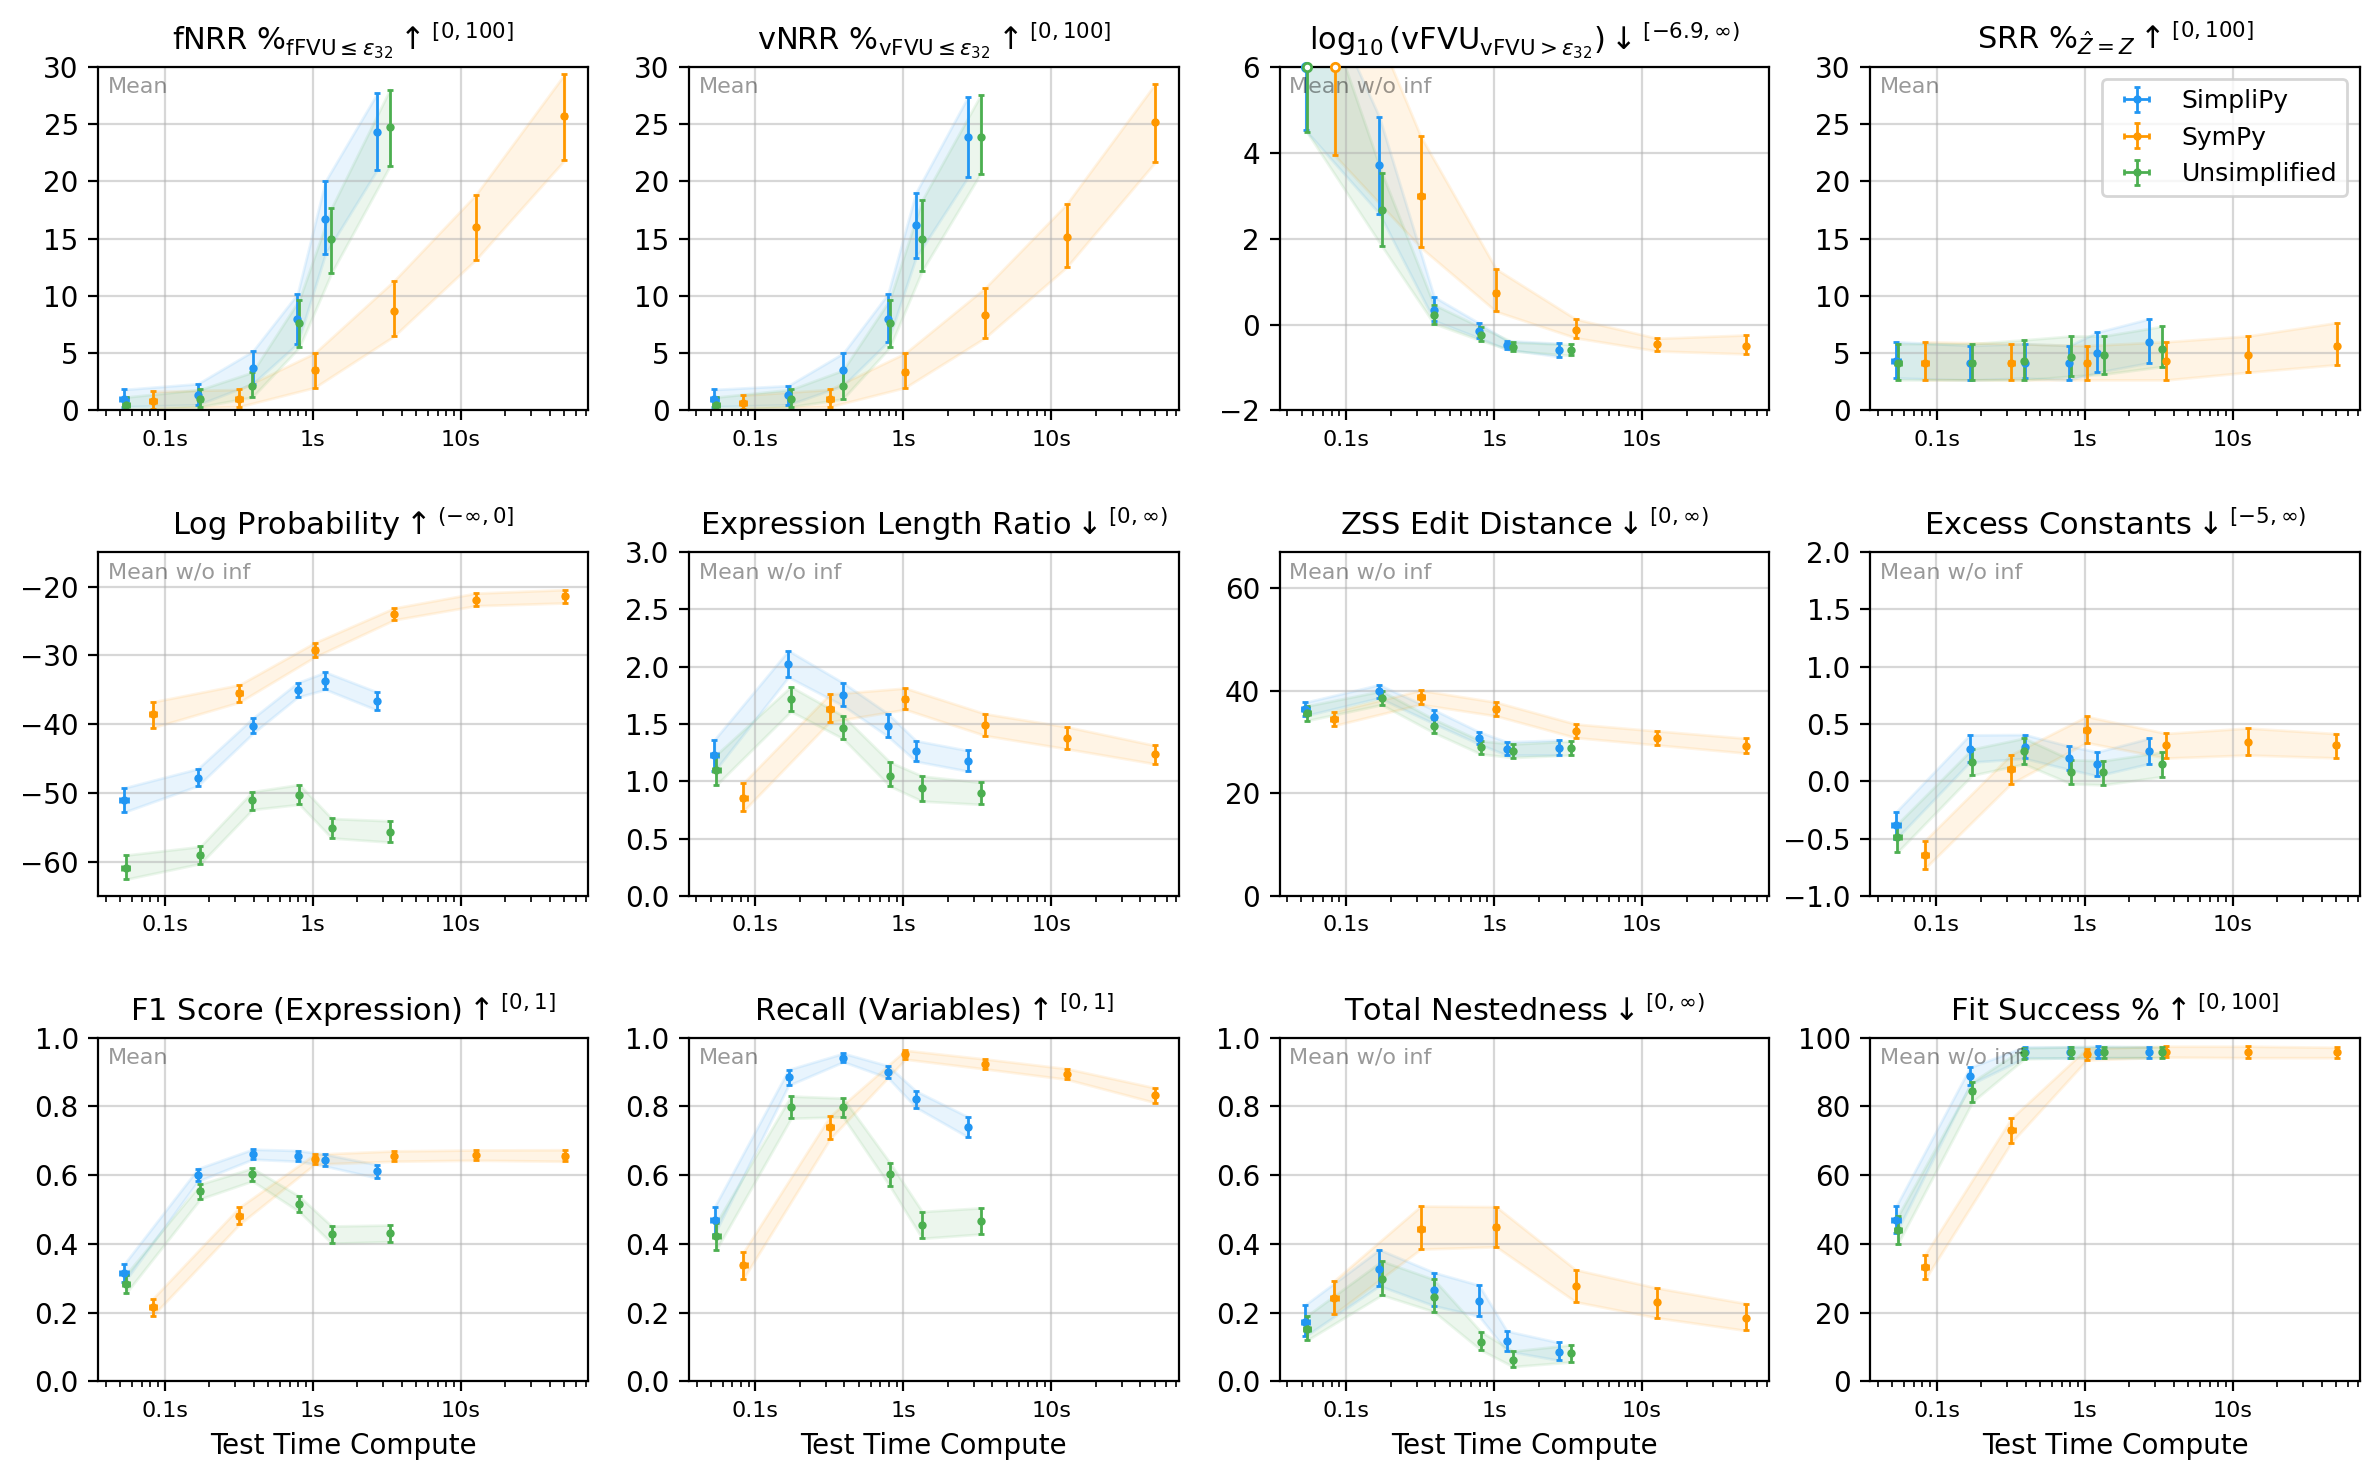

In [80]:
first_model = list(results.keys())[0]
gt_constants = results[first_model]['results'][TEST_SETS[0]][1]['n_constants']
max_gt_constants = max(gt_constants[np.isfinite(gt_constants)])

metric_pairs = [
    (('fit_time', 'Test Time Compute', naninfmean), (
        'numeric_recovery_fit',
        f'fNRR $\\%_{{\\mathrm{{fFVU}} \leq \epsilon_{{32}}}} {arrow_notation(objective=1, lower=0, upper=100)}$',
        np.nanmean,
        100,
        (0, 30)
    )),
    (('fit_time', 'Test Time Compute', naninfmean), (
        'numeric_recovery_val',
        f'vNRR $\\%_{{\\mathrm{{vFVU}} \leq \epsilon_{{32}}}} {arrow_notation(objective=1, lower=0, upper=100)}$',
        np.nanmean,
        100,
        (0, 30)
    )),
    (('fit_time', 'Test Time Compute', naninfmean), (
        'only_approx_log10_fvu_val',
        f'$\\log_{{10}}(\mathrm{{vFVU}}_{{\\mathrm{{vFVU}} > \epsilon_{{32}}}}) {arrow_notation(objective=-1, lower=np.log10(np.finfo(np.float32).eps), upper=np.inf)}$',
        naninfmean,
        1,
        (-2, 6)
    )),
    (('fit_time', 'Test Time Compute', naninfmean), (
        'symbolic_recovery',
        f'SRR $\\%_{{\hat{{Z}} = Z}} {arrow_notation(objective=1, lower=0, upper=100)}$',
        np.nanmean,
        100,
        (0, 30)
    )),
    (('fit_time', 'Test Time Compute', naninfmean), (
        'predicted_log_prob',
        f'$\mathrm{{Log\\ Probability}} {arrow_notation(objective=1, lower=-np.inf, upper=0)}$',
        naninfmean,
        1,
        (-65, -15)
    )),
    (('fit_time', 'Test Time Compute', naninfmean), (
        'skeleton_length_ratio',
        f'$\mathrm{{Expression\\ Length\\ Ratio}} {arrow_notation(objective=-1, lower=0, upper=np.inf)}$',
        naninfmean,
        1,
        (0, 3)
    )),
    (('fit_time', 'Test Time Compute', naninfmean), (
        'zss_edit_distance',
        f'$\mathrm{{ZSS\\ Edit\\ Distance}} {arrow_notation(objective=-1, lower=0, upper=np.inf)}$',
        naninfmean,
        1,
        (0, 67)
    )),
    (('fit_time', 'Test Time Compute', naninfmean), (
        'n_constants_delta',
        f'$\mathrm{{Excess\\ Constants}} {arrow_notation(objective=-1, lower=-max_gt_constants, upper=np.inf)}$',
        naninfmean,
        1,
        (-1, 2)
    )),
    (('fit_time', 'Test Time Compute', naninfmean), (
        'f1_score',
        f'$\mathrm{{F1\\ Score\\ (Expression)}} {arrow_notation(objective=1, lower=0, upper=1)}$',
        np.nanmean,
        1,
        (0.0, 1)
    )),
    (('fit_time', 'Test Time Compute', naninfmean), (
        'recall_unique_variables',
        f'$\mathrm{{Recall\\ (Variables)}} {arrow_notation(objective=1, lower=0, upper=1)}$',
        np.nanmean,
        1,
        (0, 1)
    )),
    (('fit_time', 'Test Time Compute', naninfmean), (
        'predicted_total_nestedness',
        f'$\mathrm{{Total\\ Nestedness}} {arrow_notation(objective=-1, lower=0, upper=np.inf)}$',
        naninfmean,
        1,
        (0, 1)
    )),
    (('fit_time', 'Test Time Compute', naninfmean), (
        'prediction_success',
        f'$\mathrm{{Fit\\ Success}}\\ \\% {arrow_notation(objective=1, lower=0, upper=100)}$',
        naninfmean,
        100,
        (0, 100)
    )),
]

models = [
    ('v23.0-20M-A-S1', 'choices', '#2196F3', 'SimpliPy'),
    ('v23.0-20M-A-Y1', 'choices', '#FF9800', 'SymPy'),
    ('v23.0-20M-A-U1', 'choices', '#4CAF50', 'Unsimplified'),
    # ('v23.0-20M-A-Y50K', 'choices', '#E91E63', 'SymPy 50K'),
    # ('v23.0-20M-A-Y1-simplipy-infer', 'choices', '#9C27B0', 'SymPy (SimpliPy infer)'),
]

models = [m for m in models if m[0] in results.keys()]

COLS = min(4, len(metric_pairs))
ROWS = np.ceil(len(metric_pairs) / COLS).astype(int)

test_set = 'fastsrb'

fig, axes = plt.subplots(ROWS, COLS, figsize=(3 * COLS, 2.5 * ROWS), dpi=200)

for ax_id, (ax, ((x_metric, x_label, x_statistic), (y_metric, y_label, y_statistic, y_factor, ylim))) in enumerate(zip(axes.flatten(), metric_pairs)):
    ax: plt.Axes
    for model_name, scaling_param, color, model_label in models:
        x_median, x_lower, x_upper = [], [], []
        y_median, y_lower, y_upper = [], [], []

        if model_name not in results or test_set not in results[model_name]['results']:
            continue

        for n in results[model_name]['results'][test_set].keys():
            x = results[model_name]['results'][test_set][n][x_metric]
            y = results[model_name]['results'][test_set][n][y_metric]

            # For the only_approx_log10_fvu_val, we want to ignore -inf values in the CI computation
            if y_metric == 'only_approx_log10_fvu_val':
                y = y[y != -np.inf]

            x_ci = bootstrapped_metric_ci(x, x_statistic, n=1e3, interval=0.95)
            y_ci = bootstrapped_metric_ci(y, y_statistic, n=1e3, interval=0.95)

            x_median.append(x_ci[0])
            x_lower.append(x_ci[1])
            x_upper.append(x_ci[2])
            
            y_median.append(y_ci[0])
            y_lower.append(y_ci[1])
            y_upper.append(y_ci[2])

        if ylim[0] is not None and ylim[1] is not None:
            ax.set_ylim(ylim)

        x_median, x_lower, x_upper, y_median, y_lower, y_upper = np.array(x_median), np.array(x_lower), np.array(x_upper), np.array(y_median) * y_factor, np.array(y_lower) * y_factor, np.array(y_upper) * y_factor

        ax.errorbar(x_median, y_median, yerr=[y_median - y_lower, y_upper - y_median], xerr=[x_median - x_lower, x_upper - x_median], fmt='.', label=model_label, capsize=1, color=color, elinewidth=1, markersize=4)
        ax.fill_between(x_median, y_lower, y_upper, color=color, alpha=0.1)

        # Out-of-bounds Indicators (Upper Limit)
        if ylim[1] is not None:
            upper_limit = ylim[1]
            oob_mask = y_median > upper_limit

            if np.any(oob_mask):
                ax.plot(
                    x_median[oob_mask], 
                    np.full(oob_mask.sum(), upper_limit),
                    marker='o', 
                    linestyle='None', 
                    markerfacecolor='white', 
                    markeredgecolor=color, 
                    markeredgewidth=1.0,
                    markersize=3, 
                    clip_on=False,
                    zorder=100
                )

    y_statistic_name = {
        np.nanmean: f'Mean',
        np.nanmedian: f'Median',
        naninfmean: f'Mean w/o inf',
    }

    ax.annotate(y_statistic_name[y_statistic], xy=(0.02, 0.97), xycoords='axes fraction', fontsize=8, color='k', ha='left', va='top', alpha=0.4)

    if ax_id // COLS == ROWS - 1:
        ax.set_xlabel(x_label)
        x_ticks_fontsize=8
    else:
        x_ticks_fontsize=8

    ax.set_title(y_label, fontsize=11)
    ax.set_xscale('log')
    ax.set_xticks([0.1, 1, 10])
    ax.set_xticklabels(['0.1s', '1s', '10s'], fontsize=x_ticks_fontsize)

    ax.grid(alpha=0.5)

axes.flatten()[3].legend(fontsize=9)

for ax_id, ax in enumerate(axes.flatten()[len(metric_pairs):]):
    ax.axis('off')

fig.tight_layout(w_pad=0.5, h_pad=2)

In [70]:
# Investigate NRR drop at 1024 choices for SymPy variants
print("=== NRR (fit) at each scaling value ===")
for model_name in ['v23.0-20M-A-Y1', 'v23.0-20M-A-Y50K']:
    if model_name not in results:
        print(f"{model_name} not found, skipping")
        continue
    print(f"\n{model_name}:")
    for n in sorted(results[model_name]['results']['fastsrb'].keys()):
        r = results[model_name]['results']['fastsrb'][n]
        nrr_fit = np.nanmean(r['numeric_recovery_fit']) * 100
        nrr_val = np.nanmean(r['numeric_recovery_val']) * 100
        srr = np.nanmean(r['symbolic_recovery']) * 100
        fit_success = np.nanmean(r['prediction_success']) * 100
        mean_fit_time = naninfmean(r['fit_time'])
        print(f"  choices={n:5d}: fNRR={nrr_fit:6.2f}%, vNRR={nrr_val:6.2f}%, SRR={srr:6.2f}%, fit_success={fit_success:6.2f}%, mean_fit_time={mean_fit_time:.3f}s")

=== NRR (fit) at each scaling value ===

v23.0-20M-A-Y1:
  choices=    1: fNRR=  0.83%, vNRR=  0.67%, SRR=  4.17%, fit_success= 33.33%, mean_fit_time=0.083s
  choices=    4: fNRR=  1.00%, vNRR=  1.00%, SRR=  4.17%, fit_success= 73.00%, mean_fit_time=0.319s
  choices=   16: fNRR=  3.50%, vNRR=  3.33%, SRR=  4.17%, fit_success= 95.17%, mean_fit_time=1.031s
  choices=   64: fNRR=  8.83%, vNRR=  8.50%, SRR=  4.33%, fit_success= 95.83%, mean_fit_time=3.558s
  choices=  256: fNRR= 16.00%, vNRR= 15.33%, SRR=  4.83%, fit_success= 95.83%, mean_fit_time=12.683s
  choices= 1024: fNRR= 25.67%, vNRR= 25.00%, SRR=  5.67%, fit_success= 95.83%, mean_fit_time=50.345s

v23.0-20M-A-Y50K:
  choices=    1: fNRR=  0.17%, vNRR=  0.17%, SRR=  4.17%, fit_success= 27.17%, mean_fit_time=0.077s
  choices=    4: fNRR=  1.33%, vNRR=  1.33%, SRR=  4.17%, fit_success= 70.17%, mean_fit_time=0.252s
  choices=   16: fNRR=  3.33%, vNRR=  3.33%, SRR=  4.17%, fit_success= 94.83%, mean_fit_time=0.752s
  choices=   64: fNRR=

In [71]:
# Compare fit success and NRR for SymPy models vs SimpliPy
# Also look at what happens to predictions that succeed - is NRR conditional on success also worse?
print("=== NRR conditional on fit success ===")
for model_name in ['v23.0-20M-A-S1', 'v23.0-20M-A-Y1', 'v23.0-20M-A-Y50K']:
    if model_name not in results:
        continue
    print(f"\n{model_name}:")
    for n in sorted(results[model_name]['results']['fastsrb'].keys()):
        r = results[model_name]['results']['fastsrb'][n]
        success_mask = np.array(r['prediction_success'], dtype=bool)
        n_success = success_mask.sum()
        n_total = len(success_mask)
        
        if n_success > 0:
            nrr_fit_given_success = np.nanmean(r['numeric_recovery_fit'][success_mask]) * 100
            nrr_val_given_success = np.nanmean(r['numeric_recovery_val'][success_mask]) * 100
        else:
            nrr_fit_given_success = 0
            nrr_val_given_success = 0
        
        print(f"  choices={n:5d}: success={n_success}/{n_total} ({n_success/n_total*100:.1f}%), "
              f"fNRR|success={nrr_fit_given_success:.2f}%, vNRR|success={nrr_val_given_success:.2f}%")

=== NRR conditional on fit success ===

v23.0-20M-A-S1:
  choices=    1: success=282/600 (47.0%), fNRR|success=2.13%, vNRR|success=2.13%
  choices=    4: success=533/600 (88.8%), fNRR|success=1.50%, vNRR|success=1.50%
  choices=   16: success=575/600 (95.8%), fNRR|success=3.83%, vNRR|success=3.65%
  choices=   64: success=575/600 (95.8%), fNRR|success=8.35%, vNRR|success=8.35%
  choices=  256: success=575/600 (95.8%), fNRR|success=17.57%, vNRR|success=16.87%
  choices= 1024: success=575/600 (95.8%), fNRR|success=25.39%, vNRR|success=24.87%

v23.0-20M-A-Y1:
  choices=    1: success=200/600 (33.3%), fNRR|success=2.50%, vNRR|success=2.00%
  choices=    4: success=438/600 (73.0%), fNRR|success=1.37%, vNRR|success=1.37%
  choices=   16: success=571/600 (95.2%), fNRR|success=3.68%, vNRR|success=3.50%
  choices=   64: success=575/600 (95.8%), fNRR|success=9.22%, vNRR|success=8.87%
  choices=  256: success=575/600 (95.8%), fNRR|success=16.70%, vNRR|success=16.00%
  choices= 1024: success=575/6

In [72]:
# Look at predicted expression complexity and number of constants at different choice levels
# This helps understand why fit success drops - are models choosing more complex expressions?
print("=== Expression complexity and constants at each scaling value ===")
for model_name in ['v23.0-20M-A-S1', 'v23.0-20M-A-Y1', 'v23.0-20M-A-Y50K']:
    if model_name not in results:
        continue
    print(f"\n{model_name}:")
    for n in sorted(results[model_name]['results']['fastsrb'].keys()):
        r = results[model_name]['results']['fastsrb'][n]
        success_mask = np.array(r['prediction_success'], dtype=bool)
        fail_mask = ~success_mask
        
        pred_len = r['predicted_skeleton_prefix_length']
        pred_n_const = r['predicted_n_constants']
        
        mean_len_success = naninfmean(pred_len[success_mask]) if success_mask.sum() > 0 else float('nan')
        mean_len_fail = naninfmean(pred_len[fail_mask]) if fail_mask.sum() > 0 else float('nan')
        mean_const_success = naninfmean(pred_n_const[success_mask]) if success_mask.sum() > 0 else float('nan')
        mean_const_fail = naninfmean(pred_n_const[fail_mask]) if fail_mask.sum() > 0 else float('nan')
        
        print(f"  choices={n:5d}: "
              f"avg_pred_len(success)={mean_len_success:.1f}, avg_pred_len(fail)={mean_len_fail:.1f}, "
              f"avg_pred_consts(success)={mean_const_success:.1f}, avg_pred_consts(fail)={mean_const_fail:.1f}")

=== Expression complexity and constants at each scaling value ===

v23.0-20M-A-S1:
  choices=    1: avg_pred_len(success)=20.7, avg_pred_len(fail)=0.0, avg_pred_consts(success)=1.9, avg_pred_consts(fail)=0.0
  choices=    4: avg_pred_len(success)=19.2, avg_pred_len(fail)=0.0, avg_pred_consts(success)=1.8, avg_pred_consts(fail)=0.0
  choices=   16: avg_pred_len(success)=15.4, avg_pred_len(fail)=0.0, avg_pred_consts(success)=1.7, avg_pred_consts(fail)=0.0
  choices=   64: avg_pred_len(success)=12.8, avg_pred_len(fail)=0.0, avg_pred_consts(success)=1.6, avg_pred_consts(fail)=0.0
  choices=  256: avg_pred_len(success)=11.0, avg_pred_len(fail)=0.0, avg_pred_consts(success)=1.5, avg_pred_consts(fail)=0.0
  choices= 1024: avg_pred_len(success)=10.5, avg_pred_len(fail)=0.0, avg_pred_consts(success)=1.6, avg_pred_consts(fail)=0.0

v23.0-20M-A-Y1:
  choices=    1: avg_pred_len(success)=20.5, avg_pred_len(fail)=0.0, avg_pred_consts(success)=1.9, avg_pred_consts(fail)=0.0
  choices=    4: avg_pred

In [73]:
# Check what errors are causing failures
# Also check the distribution of predicted_n_constants for failed predictions
for model_name in ['v23.0-20M-A-Y1', 'v23.0-20M-A-Y50K']:
    if model_name not in results:
        continue
    print(f"\n{'='*60}")
    print(f"{model_name}")
    print(f"{'='*60}")
    for n in sorted(results[model_name]['results']['fastsrb'].keys()):
        r = results[model_name]['results']['fastsrb'][n]
        success_mask = np.array(r['prediction_success'], dtype=bool)
        
        errors = r.get('error', [None] * len(success_mask))
        error_counts = {}
        for i, err in enumerate(errors):
            if not success_mask[i]:
                err_type = str(type(err).__name__) if err is not None else 'None (no error recorded)'
                if err_type not in error_counts:
                    error_counts[err_type] = 0
                error_counts[err_type] += 1
        
        print(f"\n  choices={n}: {success_mask.sum()}/{len(success_mask)} success, {(~success_mask).sum()} failures")
        for err_type, count in sorted(error_counts.items(), key=lambda x: -x[1]):
            print(f"    {err_type}: {count}")


v23.0-20M-A-Y1

  choices=1: 200/600 success, 400 failures
    str: 400

  choices=4: 438/600 success, 162 failures
    str: 162

  choices=16: 571/600 success, 29 failures
    str: 29

  choices=64: 575/600 success, 25 failures
    str: 25

  choices=256: 575/600 success, 25 failures
    str: 25

  choices=1024: 575/600 success, 25 failures
    str: 25

v23.0-20M-A-Y50K

  choices=1: 163/600 success, 437 failures
    str: 437

  choices=4: 421/600 success, 179 failures
    str: 179

  choices=16: 569/600 success, 31 failures
    str: 31

  choices=64: 575/600 success, 25 failures
    str: 25

  choices=256: 575/600 success, 25 failures
    str: 25

  choices=1024: 575/600 success, 25 failures
    str: 25


In [74]:
# Check actual error messages for failures
from collections import Counter

for model_name in ['v23.0-20M-A-Y1', 'v23.0-20M-A-Y50K']:
    if model_name not in results:
        continue
    print(f"\n{'='*60}")
    print(f"{model_name}")
    print(f"{'='*60}")
    for n in [64, 256, 1024]:
        r = results[model_name]['results']['fastsrb'][n]
        success_mask = np.array(r['prediction_success'], dtype=bool)
        errors = r.get('error', [None] * len(success_mask))
        
        fail_errors = [str(errors[i])[:80] for i in range(len(errors)) if not success_mask[i] and errors[i] is not None]
        error_counter = Counter(fail_errors)
        
        print(f"\n  choices={n}: Top errors ({len(fail_errors)} total failures with error msg):")
        for err_msg, count in error_counter.most_common(5):
            print(f"    [{count:3d}x] {err_msg}")


v23.0-20M-A-Y1

  choices=64: Top errors (25 total failures with error msg):
    [ 25x] max_trials_exhausted

  choices=256: Top errors (25 total failures with error msg):
    [ 25x] max_trials_exhausted

  choices=1024: Top errors (25 total failures with error msg):
    [ 25x] max_trials_exhausted

v23.0-20M-A-Y50K

  choices=64: Top errors (25 total failures with error msg):
    [ 25x] max_trials_exhausted

  choices=256: Top errors (25 total failures with error msg):
    [ 25x] max_trials_exhausted

  choices=1024: Top errors (25 total failures with error msg):
    [ 25x] max_trials_exhausted


In [75]:
# Full error breakdown for all models and choices
from collections import Counter

for model_name in ['v23.0-20M-A-S1', 'v23.0-20M-A-Y1', 'v23.0-20M-A-Y50K']:
    if model_name not in results:
        continue
    print(f"\n{'='*60}")
    print(f"{model_name}")
    print(f"{'='*60}")
    for n in sorted(results[model_name]['results']['fastsrb'].keys()):
        r = results[model_name]['results']['fastsrb'][n]
        success_mask = np.array(r['prediction_success'], dtype=bool)
        errors = r.get('error', [None] * len(success_mask))
        
        # Count all error types including None
        error_counter = Counter()
        for i in range(len(errors)):
            if not success_mask[i]:
                err = errors[i]
                if err is None:
                    error_counter['(no error)'] += 1
                else:
                    error_counter[str(err)] += 1
        
        # Group errors
        n_pow = sum(v for k, v in error_counter.items() if k.startswith("'pow"))
        n_re = error_counter.get("'re'", 0)
        n_zoo = error_counter.get("'zoo'", 0)
        n_max_trials = error_counter.get("max_trials_exhausted", 0)
        n_other = sum(error_counter.values()) - n_pow - n_re - n_zoo - n_max_trials
        n_fail = (~success_mask).sum()
        
        print(f"  choices={n:5d}: fails={n_fail:3d}/600 | pow*={n_pow:3d} re={n_re:3d} zoo={n_zoo:3d} max_trials={n_max_trials:3d} other={n_other:3d}")


v23.0-20M-A-S1
  choices=    1: fails=318/600 | pow*=  0 re=  0 zoo=  0 max_trials= 25 other=293
  choices=    4: fails= 67/600 | pow*=  0 re=  0 zoo=  0 max_trials= 25 other= 42
  choices=   16: fails= 25/600 | pow*=  0 re=  0 zoo=  0 max_trials= 25 other=  0
  choices=   64: fails= 25/600 | pow*=  0 re=  0 zoo=  0 max_trials= 25 other=  0
  choices=  256: fails= 25/600 | pow*=  0 re=  0 zoo=  0 max_trials= 25 other=  0
  choices= 1024: fails= 25/600 | pow*=  0 re=  0 zoo=  0 max_trials= 25 other=  0

v23.0-20M-A-Y1
  choices=    1: fails=400/600 | pow*=  0 re=  0 zoo=  0 max_trials= 25 other=375
  choices=    4: fails=162/600 | pow*=  0 re=  0 zoo=  0 max_trials= 25 other=137
  choices=   16: fails= 29/600 | pow*=  0 re=  0 zoo=  0 max_trials= 25 other=  4
  choices=   64: fails= 25/600 | pow*=  0 re=  0 zoo=  0 max_trials= 25 other=  0
  choices=  256: fails= 25/600 | pow*=  0 re=  0 zoo=  0 max_trials= 25 other=  0
  choices= 1024: fails= 25/600 | pow*=  0 re=  0 zoo=  0 max_trial

In [76]:
from collections import Counter

print("is_valid(['zoo']):", engine.is_valid(['zoo']))
print("is_valid(['zoo'], verbose=True):", engine.is_valid(['zoo'], verbose=True))

for model_name in ['v23.0-20M-A-Y1', 'v23.0-20M-A-Y50K']:
    if model_name not in results:
        continue
    r = results[model_name]['results']['fastsrb'][1024]
    success_mask = np.array(r['prediction_success'], dtype=bool)
    errors = r.get('error', [None] * len(success_mask))
    fail_errors = [str(errors[i]) for i in range(len(errors)) if not success_mask[i] and errors[i] is not None]
    error_counter = Counter(fail_errors)
    print(f"\nAll unique errors ({model_name}, choices=1024):")
    for err_msg, count in error_counter.most_common():
        print(f"  [{count:3d}x] {err_msg[:120]}")

is_valid(['zoo']): True
is_valid(['zoo'], verbose=True): True

All unique errors (v23.0-20M-A-Y1, choices=1024):
  [ 25x] max_trials_exhausted

All unique errors (v23.0-20M-A-Y50K, choices=1024):
  [ 25x] max_trials_exhausted


In [77]:
# Compare sympy-simplipy-infer vs pure simplipy across key metrics at each choices level
key_metrics = [
    ('numeric_recovery_val', 'vNRR %', np.nanmean, 100),
    ('symbolic_recovery', 'SRR %', np.nanmean, 100),
    ('prediction_success', 'Fit Success %', np.nanmean, 100),
    ('only_approx_log10_fvu_val', 'log10(vFVU)approx', naninfmean, 1),
    ('f1_score', 'F1 (Expr)', np.nanmean, 1),
    ('zss_edit_distance', 'ZSS Edit Dist', naninfmean, 1),
    ('skeleton_length_ratio', 'Length Ratio', naninfmean, 1),
    ('predicted_total_nestedness', 'Nestedness', naninfmean, 1),
    ('n_constants_delta', 'Excess Consts', naninfmean, 1),
    ('recall_unique_variables', 'Recall (Vars)', np.nanmean, 1),
]

compare_models = ['v23.0-20M-A-S1', 'v23.0-20M-A-Y1-simplipy-infer', 'v23.0-20M-A-Y1']
compare_labels = ['SimpliPy', 'Sy+SP@inf', 'SymPy']

scaling_vals = sorted(results[compare_models[0]]['results']['fastsrb'].keys())

# Only show a few key choices levels
for n in [16, 256, 1024]:
    if n not in scaling_vals:
        continue
    lines = []
    lines.append(f"\nchoices = {n}")
    lines.append(f"{'Metric':<20s} {'SimpliPy':>10s} {'Sy+SP@inf':>10s} {'SymPy':>10s}")
    lines.append("-" * 52)
    
    for metric_key, metric_name, stat_fn, factor in key_metrics:
        row = f"{metric_name:<20s} "
        for model_name in compare_models:
            if model_name not in results:
                row += f"{'N/A':>10s}"
                continue
            r = results[model_name]['results']['fastsrb'][n]
            y = r[metric_key]
            if metric_key == 'only_approx_log10_fvu_val':
                y = y[y != -np.inf]
            val = stat_fn(y) * factor
            row += f"{val:>10.2f}"
        lines.append(row)
    
    print('\n'.join(lines))


choices = 16
Metric                 SimpliPy  Sy+SP@inf      SymPy
----------------------------------------------------
vNRR %                     3.50      3.83      3.33
SRR %                      4.17      4.33      4.17
Fit Success %             95.83     94.17     95.17
log10(vFVU)approx          0.34      0.92      0.77
F1 (Expr)                  0.66      0.65      0.65
ZSS Edit Dist             34.91     34.38     36.43
Length Ratio               1.75      1.61      1.72
Nestedness                 0.27      0.40      0.45
Excess Consts              0.30      0.32      0.45
Recall (Vars)              0.94      0.93      0.95

choices = 256
Metric                 SimpliPy  Sy+SP@inf      SymPy
----------------------------------------------------
vNRR %                    16.17     15.17     15.33
SRR %                      5.00      4.67      4.83
Fit Success %             95.83     95.83     95.83
log10(vFVU)approx         -0.48     -0.46     -0.47
F1 (Expr)                  0.

In [78]:
# Error breakdown for sympy-simplipy-infer - does it also have the OOV token problem?
from collections import Counter
model_name = 'v23.0-20M-A-Y1-simplipy-infer'
if model_name in results:
    print(f"{model_name} - Error breakdown:")
    for n in sorted(results[model_name]['results']['fastsrb'].keys()):
        r = results[model_name]['results']['fastsrb'][n]
        success_mask = np.array(r['prediction_success'], dtype=bool)
        errors = r.get('error', [None] * len(success_mask))
        error_counter = Counter()
        for i in range(len(errors)):
            if not success_mask[i]:
                err = errors[i]
                error_counter[str(err) if err is not None else '(no error)'] += 1
        n_pow = sum(v for k, v in error_counter.items() if k.startswith("'pow"))
        n_re = error_counter.get("'re'", 0)
        n_zoo = error_counter.get("'zoo'", 0)
        n_max_trials = error_counter.get("max_trials_exhausted", 0)
        n_other = sum(error_counter.values()) - n_pow - n_re - n_zoo - n_max_trials
        n_fail = (~success_mask).sum()
        print(f"  choices={n:5d}: fails={n_fail:3d}/600 | pow*={n_pow:3d} re={n_re:3d} zoo={n_zoo:3d} max_trials={n_max_trials:3d} other={n_other:3d}")
else:
    print("Model not found")

v23.0-20M-A-Y1-simplipy-infer - Error breakdown:
  choices=    1: fails=390/600 | pow*=  0 re=  0 zoo=  0 max_trials= 25 other=365
  choices=    4: fails=138/600 | pow*=  0 re=  0 zoo=  0 max_trials= 25 other=113
  choices=   16: fails= 35/600 | pow*=  0 re=  0 zoo=  0 max_trials= 25 other= 10
  choices=   64: fails= 25/600 | pow*=  0 re=  0 zoo=  0 max_trials= 25 other=  0
  choices=  256: fails= 25/600 | pow*=  0 re=  0 zoo=  0 max_trials= 25 other=  0
  choices= 1024: fails= 25/600 | pow*=  0 re=  0 zoo=  0 max_trials= 25 other=  0
